# Week 4 — Evaluation, Feature Importance, and Business Reporting 
## Restaurant Demand Forecasting / Inventory Optimization
**Project:** Food & Restaurant Services - AI Demand Forecasting and Inventory Optimization 

**Dataset:** Kaggle Store Sales Time Series Forecasting

***Goal:***  Evaluate the forecasting model using MAE and RMSE, analyze feature importance, visualize predicted vs actual sales

## 1. Setup and Load Data

In [2]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from sklearn.metrics import mean_absolute_error, mean_squared_error
from xgboost import XGBRegressor

import joblib

# ── Settings ────────────────────────────────────────────
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')

# ── Custom Paths (YOUR PC PATHS) ────────────────────────
project_root = Path(r"C:\Users\Prarthana\Desktop\Food_Resturant")

processed_dir = Path(
    r"C:\Users\Prarthana\Desktop\Food_Resturant\Processed_Files"
)

models_dir = Path(
    r"C:\Users\Prarthana\Desktop\Food_Resturant\models"
)

# ── Load datasets ───────────────────────────────────────
train_feat = pd.read_csv(
    processed_dir / 'train_features.csv',
    parse_dates=['date']
)

val_feat = pd.read_csv(
    processed_dir / 'val_features.csv',
    parse_dates=['date']
)

test_feat = pd.read_csv(
    processed_dir / 'test_features.csv',
    parse_dates=['date']
)

# ── Load trained model ──────────────────────────────────
model_path = models_dir / 'xgboost_tuned_week3.pkl'

xgb_model = joblib.load(model_path)

# ── Print Information ───────────────────────────────────
print('Train shape :', train_feat.shape)
print('Val shape   :', val_feat.shape)
print('Test shape  :', test_feat.shape)

print('\nLoaded model from:')
print(model_path)

Train shape : (1565, 25)
Val shape   : (61, 25)
Test shape  : (64, 25)

Loaded model from:
C:\Users\Prarthana\Desktop\Food_Resturant\models\xgboost_tuned_week3.pkl


## 2. Define Features and Target

In [3]:
FEATURE_COLS = [
    'total_promo_items', 'transactions', 'oil_price',
    'year', 'month', 'day', 'dayofweek', 'weekofyear',
    'quarter', 'is_weekend',
    'is_month_start', 'is_month_end',
    'is_holiday', 'holiday_level',
    'sales_lag_7', 'sales_lag_14', 'sales_lag_28',
    'rolling_mean_7', 'rolling_std_14',
    'rolling_max_7',
    'promo_lag_7', 'promo_rolling_7'
]

TARGET      = 'sales_log1p'
TARGET_RAW  = 'total_sales'

X_test = test_feat[FEATURE_COLS]

y_test = test_feat[TARGET]
y_test_raw = test_feat[TARGET_RAW]

test_dates = test_feat['date']

print('X_test shape:', X_test.shape)
print('y_test shape:', y_test.shape)

X_test shape: (64, 22)
y_test shape: (64,)


## 3. Final Test-Set Evaluation

In [4]:
# ── Predict on test set ────────────────────────────────
test_pred_log = xgb_model.predict(X_test)

# Convert predictions back to raw sales
test_pred_raw = np.expm1(test_pred_log)
test_pred_raw = np.clip(test_pred_raw, 0, None)

# ── Metrics ────────────────────────────────────────────
test_mae = mean_absolute_error(y_test_raw, test_pred_raw)

test_rmse = np.sqrt(
    mean_squared_error(y_test_raw, test_pred_raw)
)

print('═' * 60)
print(' FINAL TEST SET PERFORMANCE')
print('═' * 60)

print(f'Test MAE  : {test_mae:,.2f}')
print(f'Test RMSE : {test_rmse:,.2f}')

print('═' * 60)

════════════════════════════════════════════════════════════
 FINAL TEST SET PERFORMANCE
════════════════════════════════════════════════════════════
Test MAE  : 29,379.83
Test RMSE : 40,750.80
════════════════════════════════════════════════════════════


## 4. Forecast vs Actuals — Test Period

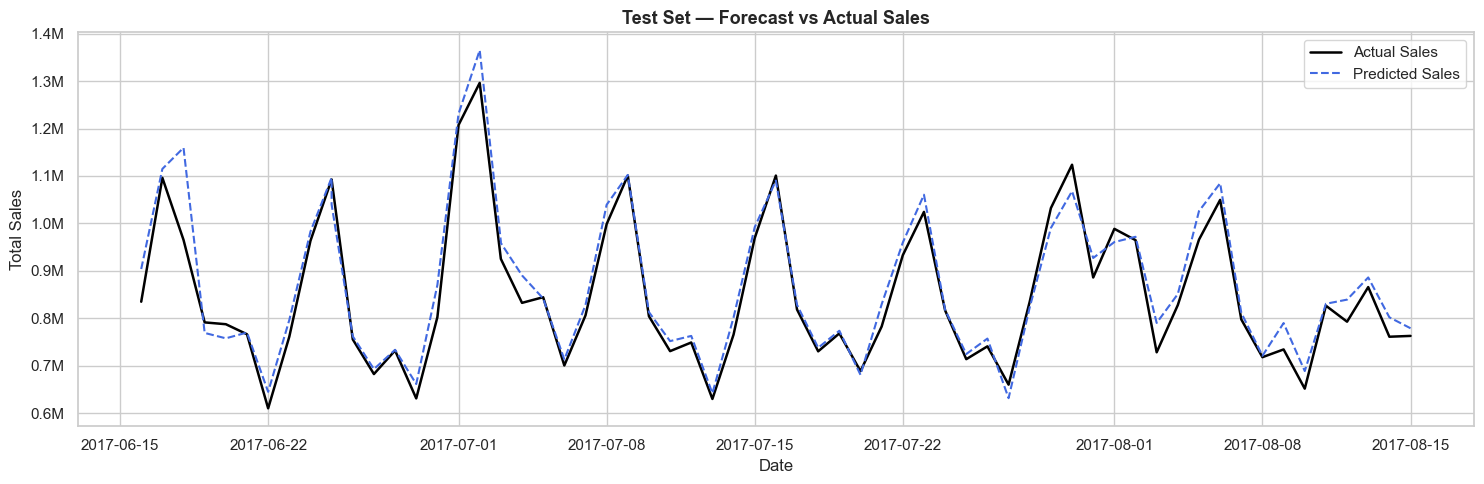

In [5]:
plt.figure(figsize=(15, 5))

plt.plot(
    test_dates,
    y_test_raw.values,
    color='black',
    linewidth=1.8,
    label='Actual Sales'
)

plt.plot(
    test_dates,
    test_pred_raw,
    color='royalblue',
    linewidth=1.5,
    linestyle='--',
    label='Predicted Sales'
)

plt.title(
    'Test Set — Forecast vs Actual Sales',
    fontsize=13,
    fontweight='bold'
)

plt.xlabel('Date')
plt.ylabel('Total Sales')

plt.gca().yaxis.set_major_formatter(
    mticker.FuncFormatter(
        lambda x, _: f'{x/1e6:.1f}M'
    )
)

plt.legend()

plt.tight_layout()

plt.savefig(
    processed_dir / 'week4_test_forecast.png',
    dpi=100,
    bbox_inches='tight'
)

plt.show()

## 5. Residual Error Analysis

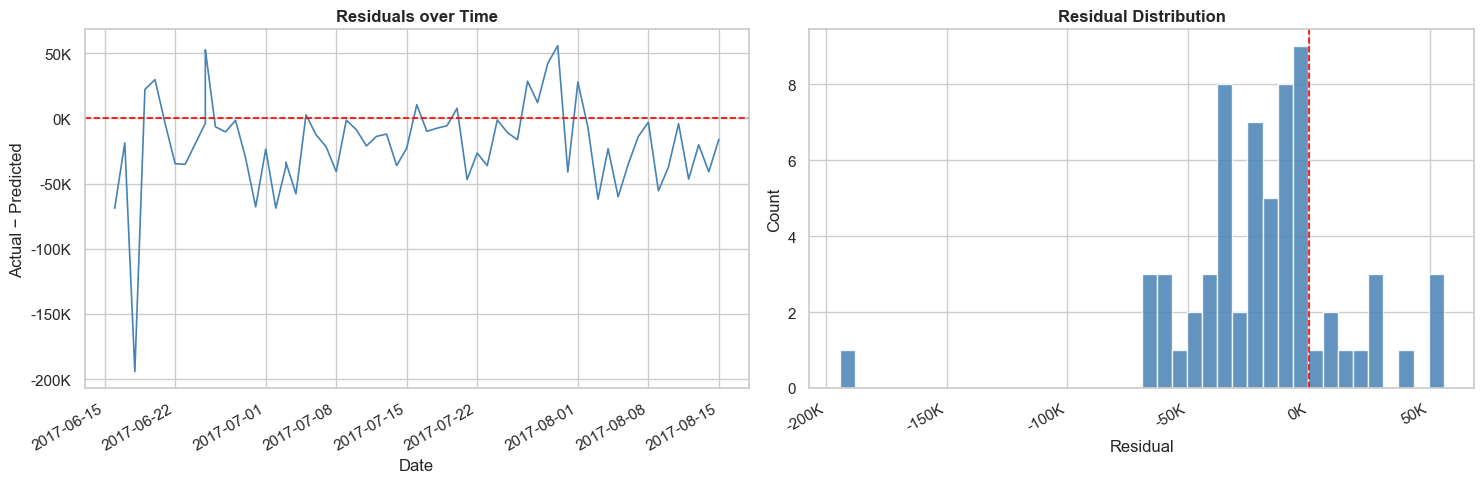

Mean residual : -18,609.64
Std residual  : 36,253.40


In [7]:
residuals = y_test_raw.values - test_pred_raw

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# ── Residuals over Time ─────────────────────────────
axes[0].plot(
    test_dates,
    residuals,
    color='steelblue',
    linewidth=1.2
)

axes[0].axhline(
    0,
    color='red',
    linestyle='--',
    linewidth=1.2
)

axes[0].set_title(
    'Residuals over Time',
    fontsize=12,
    fontweight='bold'
)

axes[0].set_xlabel('Date')
axes[0].set_ylabel('Actual − Predicted')

# Fix overlapping dates
axes[0].tick_params(axis='x', rotation=45)

# Format Y-axis
axes[0].yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'{x/1e3:.0f}K')
)

# ── Residual Distribution ───────────────────────────
axes[1].hist(
    residuals,
    bins=40,
    color='steelblue',
    edgecolor='white',
    alpha=0.85
)

axes[1].axvline(
    0,
    color='red',
    linestyle='--',
    linewidth=1.2
)

axes[1].set_title(
    'Residual Distribution',
    fontsize=12,
    fontweight='bold'
)

axes[1].set_xlabel('Residual')
axes[1].set_ylabel('Count')

# Format X-axis
axes[1].xaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'{x/1e3:.0f}K')
)

# Better spacing
fig.autofmt_xdate()

plt.tight_layout()

plt.savefig(
    processed_dir / 'week4_residual_analysis.png',
    dpi=120,
    bbox_inches='tight'
)

plt.show()

print(f'Mean residual : {residuals.mean():,.2f}')
print(f'Std residual  : {residuals.std():,.2f}')

## 6. Future Sales Forecasting

In [8]:
future_forecast = pd.DataFrame({
    'date': test_dates,
    'actual_sales': y_test_raw.values,
    'predicted_sales': test_pred_raw
})

future_forecast['forecast_error'] = (
    future_forecast['actual_sales']
    - future_forecast['predicted_sales']
)

future_forecast.head()

,date,actual_sales,predicted_sales,forecast_error
0,2017-06-16,8.347864e+05,9.037634e+05,-68977.009945
1,2017-06-17,1.096134e+06,1.114942e+06,-18808.074114
2,2017-06-18,9.651441e+05,1.159471e+06,-194326.753821
3,2017-06-19,7.911464e+05,7.689335e+05,22212.893731
4,2017-06-20,7.873267e+05,7.575619e+05,29764.842040


## 7. Business Insights from Forecasting

In [9]:
avg_actual = future_forecast['actual_sales'].mean()
avg_pred   = future_forecast['predicted_sales'].mean()

print('═' * 60)
print(' BUSINESS INSIGHTS ')
print('═' * 60)

print(f'Average Actual Daily Sales    : {avg_actual:,.2f}')
print(f'Average Predicted Daily Sales : {avg_pred:,.2f}')

high_demand_days = future_forecast[
    future_forecast['predicted_sales']
    > future_forecast['predicted_sales'].quantile(0.90)
]

print()
print('High demand forecast days:', len(high_demand_days))

print('═' * 60)

════════════════════════════════════════════════════════════
 BUSINESS INSIGHTS 
════════════════════════════════════════════════════════════
Average Actual Daily Sales    : 856,644.18
Average Predicted Daily Sales : 875,253.88

High demand forecast days: 7
════════════════════════════════════════════════════════════


## 8. Feature Importance Interpretation

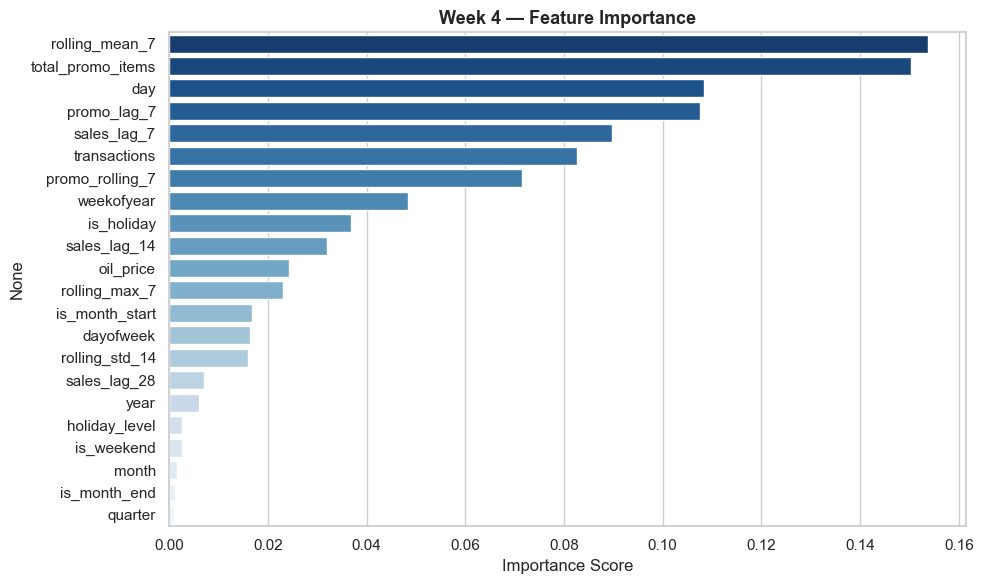


Top 5 Important Features:
rolling_mean_7       0.153680
total_promo_items    0.150341
day                  0.108370
promo_lag_7          0.107626
sales_lag_7          0.089739


In [10]:
feat_imp = pd.Series(
    xgb_model.feature_importances_,
    index=FEATURE_COLS
).sort_values(ascending=False)

plt.figure(figsize=(10, 6))

sns.barplot(
    x=feat_imp.values,
    y=feat_imp.index,
    palette='Blues_r'
)

plt.title(
    'Week 4 — Feature Importance',
    fontsize=13,
    fontweight='bold'
)

plt.xlabel('Importance Score')

plt.tight_layout()

plt.savefig(
    processed_dir / 'week4_feature_importance.png',
    dpi=100,
    bbox_inches='tight'
)

plt.show()

print('\nTop 5 Important Features:')
print(feat_imp.head(5).to_string())

## 9. Export Forecast Results

In [11]:
forecast_path = processed_dir / 'week4_forecast_results.csv'

future_forecast.to_csv(
    forecast_path,
    index=False
)

print('Forecast results saved to:')
print(forecast_path)

Forecast results saved to:
C:\Users\Prarthana\Desktop\Food_Resturant\Processed_Files\week4_forecast_results.csv


## 10. Final Business Conclusion

In [12]:
print('═' * 65)
print(' WEEK 4 — FINAL PROJECT SUMMARY ')
print('═' * 65)

print()
print(' Best model used      : Tuned XGBoost')
print(f' Final Test MAE       : {test_mae:,.2f}')
print(f' Final Test RMSE      : {test_rmse:,.2f}')

print()
print(' Key achievements:')
print('  • Built a complete demand forecasting pipeline')
print('  • Performed advanced feature engineering')
print('  • Compared multiple machine learning models')
print('  • Tuned XGBoost using TimeSeriesSplit CV')
print('  • Generated demand forecasts for business planning')
print('  • Analyzed feature importance and residual errors')

print()
print(' Business value:')
print('  • Helps optimize restaurant inventory')
print('  • Reduces overstock and food waste')
print('  • Improves demand planning accuracy')
print('  • Supports staffing and supply chain decisions')

print()
print(' Outputs generated:')
print('  • week4_test_forecast.png')
print('  • week4_residual_analysis.png')
print('  • week4_feature_importance.png')
print('  • week4_forecast_results.csv')

print()
print(' Project completed successfully.')
print('═' * 65)

═════════════════════════════════════════════════════════════════
 WEEK 4 — FINAL PROJECT SUMMARY 
═════════════════════════════════════════════════════════════════

 Best model used      : Tuned XGBoost
 Final Test MAE       : 29,379.83
 Final Test RMSE      : 40,750.80

 Key achievements:
  • Built a complete demand forecasting pipeline
  • Performed advanced feature engineering
  • Compared multiple machine learning models
  • Tuned XGBoost using TimeSeriesSplit CV
  • Generated demand forecasts for business planning
  • Analyzed feature importance and residual errors

 Business value:
  • Helps optimize restaurant inventory
  • Reduces overstock and food waste
  • Improves demand planning accuracy
  • Supports staffing and supply chain decisions

 Outputs generated:
  • week4_test_forecast.png
  • week4_residual_analysis.png
  • week4_feature_importance.png
  • week4_forecast_results.csv

 Project completed successfully.
═════════════════════════════════════════════════════════════